# Fine-Tuning LLMs with QLoRA — Final Runnable Tutorial

**Model:** Qwen2.5-1.5B-Instruct
**Method:** QLoRA (4-bit frozen base + LoRA adapters)
**Environment:** Google Colab T4 or another NVIDIA GPU

This notebook implements a controlled experiment:

1. Uses a reproducible, shuffled dataset sample.
2. Creates separate **train, validation, and final test** sets.
3. Trains on **completion tokens only** with TRL's prompt-completion format.
4. Compares the **base model and fine-tuned model** using identical prompts.
5. Reports held-out ROUGE for both models.
6. Adds a deterministic structured-JSON task with exact, field-level metrics.
7. Adds an **out-of-distribution challenge set** that separates format memorisation
   from genuine extraction.
8. Saves predictions, metrics, environment details, loss curves, and the LoRA adapter.

> Run the notebook in a fresh Colab session from top to bottom. Use
> **Runtime → Change runtime type → T4 GPU**.

> **Precision:** BF16 is enabled only on Ampere-or-newer GPUs when Hugging Face also
> reports support. T4 and V100 use FP16.

> **On interpreting the results.** A high score on the in-distribution structured test
> shows performance on records drawn from the *same four templates and twelve cities*
> the model trained on. It is not by itself evidence of general extraction ability —
> which is exactly what section 11b measures. Read both numbers together.

## 1. Install the tested training stack

The versions below match the stack that completed the earlier T4 run. They are pinned so that the tutorial does not silently move to incompatible APIs.


In [1]:
# One resolver pass prevents pip from upgrading one library outside another library's supported window.
%pip install -q \
    "unsloth==2026.7.5" \
    "trl==0.24.0" \
    "transformers==5.5.0" \
    "peft==0.19.1" \
    accelerate bitsandbytes datasets evaluate rouge_score matplotlib huggingface_hub


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 130.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 122.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 22.6 MB/s eta 0:00:00
   ━━━━━

## 2. Environment, revisions, and experiment configuration

`MODEL_REVISION` and `DATASET_REVISION` may be set to exact Hugging Face commit hashes for immutable reruns. When left as `None`, this notebook records the resolved repository SHA in `results/environment.json`.


In [4]:
from __future__ import annotations

import json
import math
import os
import platform
import random
import re
import time
import warnings
from importlib.metadata import version as package_version
from pathlib import Path
from typing import Any

# Unsloth must be imported before transformers (or anything that imports it) so its
# patches land first. Importing it late produces:
#   "WARNING: Unsloth should be imported before transformers"
# and silently skips some of its optimisations.
import unsloth  # noqa: F401  (imported for its import-time patching side effects)

import numpy as np
import torch
from datasets import Dataset, concatenate_datasets, load_dataset
from huggingface_hub import HfApi

# ------------------------------
# Reproducibility configuration
# ------------------------------
SEED = 3407
MODEL_ID = "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit"
MODEL_REVISION = None
DATASET_ID = "yahma/alpaca-cleaned"
DATASET_REVISION = None     # Optional: replace with a tested commit SHA.

MAX_SEQ_LEN = 1024
ALPACA_EXAMPLES = 1400
STRUCTURED_EXAMPLES = 600
NUM_EPOCHS = 1

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

assert torch.cuda.is_available(), (
    "No CUDA GPU detected. In Colab choose Runtime → Change runtime type → T4 GPU."
)

GPU_NAME = torch.cuda.get_device_name(0)
VRAM_GB = torch.cuda.get_device_properties(0).total_memory / 1e9
COMPUTE_CAPABILITY = torch.cuda.get_device_capability(0)

# Use the same BF16 capability check expected by Hugging Face Trainer.
# T4/V100 GPUs are pre-Ampere and must use FP16. Ampere+ GPUs may use BF16.
try:
    from transformers.utils import is_torch_bf16_gpu_available
    HF_BF16_AVAILABLE = bool(is_torch_bf16_gpu_available())
except (ImportError, AttributeError):
    HF_BF16_AVAILABLE = bool(torch.cuda.is_bf16_supported())

GPU_MAJOR = COMPUTE_CAPABILITY[0]
USE_BF16 = bool(GPU_MAJOR >= 8 and HF_BF16_AVAILABLE)
USE_FP16 = not USE_BF16

assert not (USE_BF16 and USE_FP16)

hf_api = HfApi()
resolved_model_revision = hf_api.model_info(
    MODEL_ID, revision=MODEL_REVISION
).sha
resolved_dataset_revision = hf_api.dataset_info(
    DATASET_ID, revision=DATASET_REVISION
).sha

print(f"GPU                    : {GPU_NAME}")
print(f"VRAM                   : {VRAM_GB:.1f} GB")
print(f"Compute capability     : {COMPUTE_CAPABILITY}")
print(f"Precision              : {'bf16' if USE_BF16 else 'fp16'}")
print(f"Python                 : {platform.python_version()}")
print(f"PyTorch                : {torch.__version__}")
print(f"Resolved model revision: {resolved_model_revision}")
print(f"Resolved data revision : {resolved_dataset_revision}")

EXPECTED = {
    "unsloth": "2026.7.5",
    "trl": "0.24.0",
    "transformers": "5.5.0",
    "peft": "0.19.1",
}
for package, expected_version in EXPECTED.items():
    actual_version = package_version(package)
    assert actual_version == expected_version, (
        f"{package}=={actual_version} is installed, but this notebook was tested with "
        f"{package}=={expected_version}. Re-run the install cell."
    )
    print(f"{package:12s}: {actual_version}")

GPU                    : Tesla T4
VRAM                   : 15.6 GB
Compute capability     : (7, 5)
Precision              : fp16
Python                 : 3.12.13
PyTorch                : 2.11.0+cu128
Resolved model revision: d2f2dd02b071701d5100a04a7a49d6fb0bd305b7
Resolved data revision : 12567cabf869d7c92e573c7c783905fc160e9639
unsloth     : 2026.7.5
trl         : 0.24.0
transformers: 5.5.0
peft        : 0.19.1


## 3. Load Qwen in 4-bit and attach LoRA adapters

QLoRA keeps the base model quantised and frozen. Only the low-rank adapters receive gradient updates.


In [5]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_ID,
    revision=resolved_model_revision,
    max_seq_length=MAX_SEQ_LEN,
    load_in_4bit=True,
    dtype=torch.bfloat16 if USE_BF16 else torch.float16,
)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,  # Regularisation; disables some Unsloth fused LoRA fast paths.
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    bias="none",
    use_gradient_checkpointing="unsloth",
    use_rslora=False,
    random_state=SEED,
)

model.print_trainable_parameters()

==((====))==  Unsloth 2026.7.5: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.7.5 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


## 4. Build two complementary datasets

### Dataset A — general instruction tuning

A shuffled subset of Alpaca-cleaned demonstrates ordinary instruction fine-tuning.

### Dataset B — deterministic structured output

Synthetic company records teach a precisely measurable task: converting a record into a fixed JSON schema. Its answers are generated deterministically rather than by another LLM.

Each source is split independently into:

- 80% training
- 10% validation
- 10% final test

The final test sets are never passed to the trainer or used for checkpoint selection.


In [6]:
# ------------------------------
# A. General instruction dataset
# ------------------------------
alpaca_all = load_dataset(
    DATASET_ID,
    revision=resolved_dataset_revision,
    split="train",
)

# Shuffle before selecting: never assume the stored first N rows are representative.
alpaca_all = (
    alpaca_all
    .shuffle(seed=SEED)
    .select(range(min(ALPACA_EXAMPLES, len(alpaca_all))))
)

def build_alpaca_prompt(example: dict[str, Any]) -> str:
    instruction = str(example["instruction"]).strip()
    extra_input = str(example.get("input", "") or "").strip()
    return instruction if not extra_input else f"{instruction}\n\n{extra_input}"

alpaca_80_20 = alpaca_all.train_test_split(test_size=0.20, seed=SEED)
raw_alpaca_train = alpaca_80_20["train"]
alpaca_val_test = alpaca_80_20["test"].train_test_split(test_size=0.50, seed=SEED)
raw_alpaca_validation = alpaca_val_test["train"]
raw_alpaca_test = alpaca_val_test["test"]

# ---------------------------------
# B. Deterministic structured task
# ---------------------------------
PREFIXES = [
    "Atlas", "Blue Ridge", "Cedar", "Delta", "Evergreen", "Falcon", "Granite",
    "Harbor", "Ion", "Juniper", "Keystone", "Liberty", "Magnolia", "Nova",
    "Orion", "Pioneer", "Quantum", "Redwood", "Summit", "Titan",
]
NOUNS = [
    "Battery", "Mobility", "Power", "Components", "Dynamics", "Materials",
    "Automation", "Energy", "Systems", "Manufacturing", "Technologies",
    "Logistics", "Electronics", "Motors", "Recycling",
]
SUFFIXES = ["LLC", "Inc.", "Group", "Works"]
CITIES = [
    "Athens", "Atlanta", "Augusta", "Brunswick", "Columbus", "Dalton",
    "Gainesville", "LaGrange", "Macon", "Rome", "Savannah", "Valdosta",
]
ROLE_PRODUCTS = {
    "Battery Cell": [
        "lithium-ion battery cells",
        "cell formation equipment",
        "battery electrode materials",
    ],
    "Battery Pack": [
        "battery pack assemblies",
        "battery management systems",
        "thermal management modules",
    ],
    "General Automotive": [
        "vehicle body components",
        "automotive electronics",
        "precision drivetrain parts",
    ],
    "Charging Infrastructure": [
        "DC fast chargers",
        "charging-control software",
        "commercial charging cabinets",
    ],
    "Battery Materials": [
        "cathode active material",
        "battery-grade aluminium foil",
        "electrolyte additives",
    ],
}

EXPECTED_JSON_KEYS = [
    "company_name",
    "city",
    "employee_count",
    "iso_9001",
    "supply_chain_role",
]

def create_structured_examples(n: int, seed: int) -> list[dict[str, Any]]:
    rng = random.Random(seed)

    names = [
        f"{prefix} {noun} {suffix}"
        for prefix in PREFIXES
        for noun in NOUNS
        for suffix in SUFFIXES
    ]
    rng.shuffle(names)

    examples: list[dict[str, Any]] = []
    roles = list(ROLE_PRODUCTS)

    templates = [
        (
            "Organisation: {company}\nCity: {city}\nEmployees: {employees}\n"
            "ISO 9001 certified: {cert_text}\nSupply-chain role: {role}\n"
            "Main product: {product}"
        ),
        (
            "Company record\n- Workforce: {employees}\n- Role: {role}\n"
            "- Organisation name: {company}\n- Product: {product}\n"
            "- Certification ISO 9001: {cert_text}\n- Location city: {city}"
        ),
        (
            "{company} operates in {city}. It employs {employees} people and produces "
            "{product}. Its supply-chain role is {role}. ISO 9001 status: {cert_text}."
        ),
        (
            "Location={city}; Company={company}; Product={product}; "
            "Employees={employees}; Role={role}; ISO9001={cert_text}"
        ),
    ]

    for index in range(n):
        company = names[index]
        city = rng.choice(CITIES)
        role = rng.choice(roles)
        product = rng.choice(ROLE_PRODUCTS[role])
        employees = rng.randint(25, 5000)
        certified = rng.choice([True, False])
        cert_text = rng.choice(["yes", "certified"]) if certified else rng.choice(["no", "not certified"])

        template_index = rng.randrange(len(templates))
        record_text = templates[template_index].format(
            company=company,
            city=city,
            employees=employees,
            cert_text=cert_text,
            role=role,
            product=product,
        )

        prompt_text = (
            "Convert the company record below into JSON.\n"
            "Return JSON only—no markdown and no explanation.\n"
            "Use these keys in exactly this order:\n"
            "company_name, city, employee_count, iso_9001, supply_chain_role\n"
            "Use an integer for employee_count and a JSON boolean for iso_9001.\n\n"
            f"{record_text}"
        )

        gold = {
            "company_name": company,
            "city": city,
            "employee_count": employees,
            "iso_9001": certified,
            "supply_chain_role": role,
        }

        examples.append({
            "prompt_text": prompt_text,
            "gold_json": json.dumps(gold, ensure_ascii=False),
            "template_id": template_index,
            **gold,
        })

    return examples

structured_all = Dataset.from_list(
    create_structured_examples(STRUCTURED_EXAMPLES, SEED + 1)
)
structured_80_20 = structured_all.train_test_split(test_size=0.20, seed=SEED)
raw_structured_train = structured_80_20["train"]
structured_val_test = structured_80_20["test"].train_test_split(
    test_size=0.50, seed=SEED
)
raw_structured_validation = structured_val_test["train"]
raw_structured_test = structured_val_test["test"]

print("Alpaca split:")
print(
    len(raw_alpaca_train),
    len(raw_alpaca_validation),
    len(raw_alpaca_test),
)
print("Structured split:")
print(
    len(raw_structured_train),
    len(raw_structured_validation),
    len(raw_structured_test),
)

Generating train split: 0 examples [00:00, ? examples/s]

Alpaca split:
1120 140 140
Structured split:
480 60 60


## 5. Convert both sources to TRL prompt-completion format

TRL computes loss only on `completion` tokens for a prompt-completion dataset when `completion_only_loss=True`. This avoids spending gradient updates on reproducing the user's prompt.


In [7]:
def alpaca_to_prompt_completion(example: dict[str, Any]) -> dict[str, Any]:
    return {
        "prompt": [
            {"role": "user", "content": build_alpaca_prompt(example)}
        ],
        "completion": [
            {"role": "assistant", "content": str(example["output"]).strip()}
        ],
    }

def structured_to_prompt_completion(example: dict[str, Any]) -> dict[str, Any]:
    return {
        "prompt": [
            {"role": "user", "content": str(example["prompt_text"])}
        ],
        "completion": [
            {"role": "assistant", "content": str(example["gold_json"])}
        ],
    }

def convert_split(dataset: Dataset, mapper) -> Dataset:
    return dataset.map(
        mapper,
        remove_columns=dataset.column_names,
        desc="Converting to prompt-completion format",
    )

alpaca_train_pc = convert_split(raw_alpaca_train, alpaca_to_prompt_completion)
alpaca_validation_pc = convert_split(
    raw_alpaca_validation, alpaca_to_prompt_completion
)

structured_train_pc = convert_split(
    raw_structured_train, structured_to_prompt_completion
)
structured_validation_pc = convert_split(
    raw_structured_validation, structured_to_prompt_completion
)

train_ds = concatenate_datasets([
    alpaca_train_pc,
    structured_train_pc,
]).shuffle(seed=SEED)

validation_ds = concatenate_datasets([
    alpaca_validation_pc,
    structured_validation_pc,
]).shuffle(seed=SEED)

print(f"Training examples  : {len(train_ds)}")
print(f"Validation examples: {len(validation_ds)}")
print(f"Final test examples: {len(raw_alpaca_test) + len(raw_structured_test)}")

# Always inspect the actual text that the tokenizer's template produces.
preview_messages = train_ds[0]["prompt"] + train_ds[0]["completion"]
preview = tokenizer.apply_chat_template(
    preview_messages,
    tokenize=False,
    add_generation_prompt=False,
)
print("\nFormatted preview:\n")
print(preview[:1000])


Converting to prompt-completion format:   0%|          | 0/1120 [00:00<?, ? examples/s]

Converting to prompt-completion format:   0%|          | 0/140 [00:00<?, ? examples/s]

Converting to prompt-completion format:   0%|          | 0/480 [00:00<?, ? examples/s]

Converting to prompt-completion format:   0%|          | 0/60 [00:00<?, ? examples/s]

Training examples  : 1600
Validation examples: 200
Final test examples: 200

Formatted preview:

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Produce a new slogan for a given brand.

Safeway<|im_end|>
<|im_start|>assistant
"Safeway - Shop with confidence, leave with satisfaction."<|im_end|>



## 6. Configure and train

Validation data is used only for checkpoint selection. Final reported task metrics use the untouched test sets.

`completion_only_loss=True` is explicit, so only assistant completion tokens contribute to the loss.


In [8]:
from trl import SFTConfig, SFTTrainer

PER_DEVICE_BATCH = 2
GRADIENT_ACCUMULATION = 4
EFFECTIVE_BATCH = PER_DEVICE_BATCH * GRADIENT_ACCUMULATION
steps_per_epoch = math.ceil(len(train_ds) / EFFECTIVE_BATCH)
warmup_steps = max(1, round(steps_per_epoch * NUM_EPOCHS * 0.03))

print(
    f"Trainer mixed precision: "
    f"fp16={USE_FP16}, bf16={USE_BF16}, "
    f"GPU={GPU_NAME}, capability={COMPUTE_CAPABILITY}"
)

training_args = SFTConfig(
    output_dir="outputs",
    max_length=MAX_SEQ_LEN,
    completion_only_loss=True,

    per_device_train_batch_size=PER_DEVICE_BATCH,
    per_device_eval_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION,
    num_train_epochs=NUM_EPOCHS,

    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=warmup_steps,
    weight_decay=0.01,
    max_grad_norm=1.0,
    optim="paged_adamw_8bit",

    fp16=USE_FP16,
    bf16=USE_BF16,

    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,

    packing=False,
    seed=SEED,
    data_seed=SEED,
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=train_ds,
    eval_dataset=validation_ds,
    args=training_args,
)

torch.cuda.reset_peak_memory_stats()
training_started = time.time()
trainer_stats = trainer.train()
training_wall_seconds = time.time() - training_started


Trainer mixed precision: fp16=True, bf16=False, GPU=Tesla T4, capability=(7, 5)


Unsloth: Tokenizing ["prompt"+"completion"] (num_proc=6):   0%|          | 0/1600 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["prompt"+"completion"] (num_proc=6):   0%|          | 0/200 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,600 | Num Epochs = 1 | Total steps = 200
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
50,0.891906,0.807433
100,0.827861,0.804294
150,0.927173,0.802890
200,1.006534,0.801450


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-50/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-150/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-200/tokenizer_config.json.


## 7. Training report and loss curves

The notebook reads validation results already recorded during training. It does not call the failing post-training `trainer.evaluate()` path from the previous notebook.


Runtime             : 8.9 min
Peak reserved VRAM  : 2.86 GB of 15.6 GB
Optimizer steps     : 200
Validation checks   : 4
Best validation loss: 0.8014 at step 200
Validation perplexity: 2.23


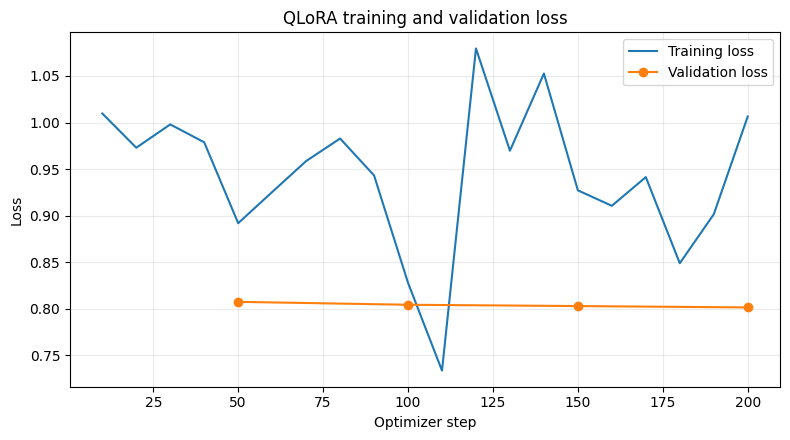

In [9]:
import matplotlib.pyplot as plt

history = trainer.state.log_history
train_points = [
    (row["step"], row["loss"])
    for row in history
    if "loss" in row and "eval_loss" not in row
]
validation_points = [
    (row["step"], row["eval_loss"])
    for row in history
    if "eval_loss" in row
]

if not validation_points:
    raise RuntimeError(
        "No validation losses were recorded. Check eval_strategy and eval_steps."
    )

best_step, best_validation_loss = min(
    validation_points, key=lambda item: item[1]
)
peak_vram_gb = torch.cuda.max_memory_reserved() / 1e9
reported_runtime = trainer_stats.metrics.get(
    "train_runtime", training_wall_seconds
)

print(f"Runtime             : {reported_runtime / 60:.1f} min")
print(f"Peak reserved VRAM  : {peak_vram_gb:.2f} GB of {VRAM_GB:.1f} GB")
print(f"Optimizer steps     : {trainer.state.global_step}")
print(f"Validation checks   : {len(validation_points)}")
print(f"Best validation loss: {best_validation_loss:.4f} at step {best_step}")
print(f"Validation perplexity: {math.exp(best_validation_loss):.2f}")

figure, axis = plt.subplots(figsize=(8, 4.5))
if train_points:
    axis.plot(
        [point[0] for point in train_points],
        [point[1] for point in train_points],
        label="Training loss",
    )
axis.plot(
    [point[0] for point in validation_points],
    [point[1] for point in validation_points],
    marker="o",
    label="Validation loss",
)
axis.set_xlabel("Optimizer step")
axis.set_ylabel("Loss")
axis.set_title("QLoRA training and validation loss")
axis.legend()
axis.grid(alpha=0.25)
figure.tight_layout()
figure.savefig(RESULTS_DIR / "loss_curves.png", dpi=160)
plt.show()


## 8. Deterministic inference helper

The helper uses only `max_length`, calculated as prompt length plus the requested output allowance. This prevents the earlier warning caused by setting both `max_length` and `max_new_tokens`.


In [10]:
from contextlib import nullcontext
from unsloth import FastLanguageModel

FastLanguageModel.for_inference(model)

# Suppress one known internal Transformers deprecation warning without hiding other warnings.
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module=r"transformers\.modeling_attn_mask_utils",
)

@torch.inference_mode()
def generate_answer(
    prompt: str,
    *,
    adapter_enabled: bool,
    max_new_tokens: int = 192,
) -> str:
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    ).to(model.device)

    prompt_tokens = int(inputs["input_ids"].shape[1])
    if prompt_tokens >= MAX_SEQ_LEN:
        raise ValueError(
            f"Prompt has {prompt_tokens} tokens, which reaches MAX_SEQ_LEN={MAX_SEQ_LEN}."
        )

    output_limit = min(
        prompt_tokens + max_new_tokens,
        MAX_SEQ_LEN,
    )

    context = nullcontext() if adapter_enabled else model.disable_adapter()
    with context:
        generated = model.generate(
            **inputs,
            max_length=output_limit,
            do_sample=False,
            num_beams=1,
            use_cache=True,
            pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    continuation = generated[0, prompt_tokens:]
    return tokenizer.decode(
        continuation,
        skip_special_tokens=True,
    ).strip()

print(
    generate_answer(
        "Explain QLoRA to a beginner in two sentences.",
        adapter_enabled=True,
    )
)


QLoRA is an advanced deep learning framework that enables researchers and developers to build large-scale models with ease. It provides efficient ways of training and deploying these models on various hardware platforms.


## 9. Qualitative base-versus-tuned comparison

The same prompts and greedy decoding settings are used for both conditions.


In [11]:
QUALITATIVE_PROMPTS = [
    "Give three tips for writing clear code.",
    "Summarize the water cycle in exactly two sentences.",
    "Return a JSON object with keys item and quantity for: five notebooks.",
    "What is the capital of Australia?",
    raw_structured_test[0]["prompt_text"],
]

qualitative_rows = []
for prompt in QUALITATIVE_PROMPTS:
    base_output = generate_answer(
        prompt,
        adapter_enabled=False,
        max_new_tokens=192,
    )
    tuned_output = generate_answer(
        prompt,
        adapter_enabled=True,
        max_new_tokens=192,
    )
    qualitative_rows.append({
        "prompt": prompt,
        "base_output": base_output,
        "tuned_output": tuned_output,
    })

for row in qualitative_rows:
    print("=" * 88)
    print("PROMPT\n", row["prompt"])
    print("\nBASE\n", row["base_output"])
    print("\nTUNED\n", row["tuned_output"])


PROMPT
 Give three tips for writing clear code.

BASE
 1. Use descriptive variable and function names: This helps other developers understand the purpose of each piece of code more easily.
2. Follow consistent coding conventions: Consistent formatting, naming conventions, and indentation can make your code easier to read and maintain.
3. Write modular code: Break down complex problems into smaller, manageable pieces that can be solved independently. This makes it easier to understand and modify the code later on.

TUNED
 1. Use meaningful variable and function names: It is important to use descriptive names that clearly indicate what the variable or function does. This will make it easier for other developers to understand your code.

2. Follow coding conventions: There are many established conventions in the industry for formatting code, such as using indentation, commenting, and naming conventions. Following these conventions makes it easier for others to read and understand your cod

## 10. Held-out Alpaca evaluation: base versus tuned

ROUGE is only a relative surface-overlap signal for open-ended answers. The important correction is that both model conditions are evaluated on the same untouched final test examples.


In [12]:
import evaluate

# 25 was too small to support even a modest retention claim. Set this to
# len(raw_alpaca_test) to use all 140 held-out rows, at the cost of more generation time
# (every example is generated twice — once per model condition).
ROUGE_TEST_EXAMPLES = min(100, len(raw_alpaca_test))
alpaca_test_sample = raw_alpaca_test.select(
    range(ROUGE_TEST_EXAMPLES)
)

rouge_references = [
    str(example["output"]).strip()
    for example in alpaca_test_sample
]
rouge_prompts = [
    build_alpaca_prompt(example)
    for example in alpaca_test_sample
]

base_rouge_predictions = [
    generate_answer(
        prompt,
        adapter_enabled=False,
        max_new_tokens=256,
    )
    for prompt in rouge_prompts
]
tuned_rouge_predictions = [
    generate_answer(
        prompt,
        adapter_enabled=True,
        max_new_tokens=256,
    )
    for prompt in rouge_prompts
]

rouge = evaluate.load("rouge")
base_rouge = rouge.compute(
    predictions=base_rouge_predictions,
    references=rouge_references,
)
tuned_rouge = rouge.compute(
    predictions=tuned_rouge_predictions,
    references=rouge_references,
)

print("Base model ROUGE")
print(json.dumps(base_rouge, indent=2))
print("\nFine-tuned model ROUGE")
print(json.dumps(tuned_rouge, indent=2))
print("\nFine-tuned minus base")
print(json.dumps({
    key: tuned_rouge[key] - base_rouge[key]
    for key in base_rouge
}, indent=2))

Base model ROUGE
{
  "rouge1": 0.4092122960027327,
  "rouge2": 0.17948827932869815,
  "rougeL": 0.28374066996876324,
  "rougeLsum": 0.3601338539680211
}

Fine-tuned model ROUGE
{
  "rouge1": 0.46156018125836473,
  "rouge2": 0.22132149396267667,
  "rougeL": 0.33404517014688095,
  "rougeLsum": 0.40417023835770477
}

Fine-tuned minus base
{
  "rouge1": 0.052347885255632054,
  "rouge2": 0.041833214633978516,
  "rougeL": 0.05030450017811772,
  "rougeLsum": 0.04403638438968366
}


## 11. Deterministic structured-JSON evaluation

This task provides stronger evidence than ROUGE because every field has an exact gold value.

Reported metrics:

- valid JSON
- exact key order
- all fields correct
- individual field accuracy


In [13]:
def extract_json_object(text: str) -> dict[str, Any] | None:
    """Parse the first complete-looking JSON object from a model response."""
    cleaned = text.strip()

    # Remove common Markdown fences if the model ignored the instruction.
    cleaned = re.sub(r"^```(?:json)?\s*", "", cleaned, flags=re.IGNORECASE)
    cleaned = re.sub(r"\s*```$", "", cleaned)

    start = cleaned.find("{")
    end = cleaned.rfind("}")
    if start < 0 or end < start:
        return None

    try:
        parsed = json.loads(cleaned[start:end + 1])
    except json.JSONDecodeError:
        return None

    return parsed if isinstance(parsed, dict) else None

def normalise_value(key: str, value: Any) -> Any:
    if key == "employee_count":
        if isinstance(value, bool):
            return None
        try:
            return int(str(value).replace(",", "").strip())
        except (TypeError, ValueError):
            return None

    if key == "iso_9001":
        if isinstance(value, bool):
            return value
        if isinstance(value, str):
            mapping = {
                "true": True,
                "yes": True,
                "certified": True,
                "false": False,
                "no": False,
                "not certified": False,
            }
            return mapping.get(value.strip().lower())
        return None

    if value is None:
        return None
    return str(value).strip().casefold()

def evaluate_structured_outputs(
    raw_dataset: Dataset,
    outputs: list[str],
) -> tuple[dict[str, float], list[dict[str, Any]]]:
    if len(raw_dataset) != len(outputs):
        raise ValueError("Dataset and output lengths differ.")

    total = len(outputs)
    valid_json = 0
    strict_json_only = 0
    exact_key_order = 0
    all_fields_correct = 0
    field_correct = {key: 0 for key in EXPECTED_JSON_KEYS}
    rows: list[dict[str, Any]] = []

    for example, output in zip(raw_dataset, outputs):
        gold = {
            key: example[key]
            for key in EXPECTED_JSON_KEYS
        }
        # extract_json_object() is deliberately forgiving: it strips markdown fences and
        # takes the span between the first '{' and last '}'. That measures recoverability,
        # not compliance — "Here you go:\n```json\n{...}```" passes. The prompt says
        # "Return JSON only", so score that separately and strictly.
        try:
            strict_is_valid = isinstance(json.loads(output.strip()), dict)
        except (json.JSONDecodeError, TypeError):
            strict_is_valid = False
        strict_json_only += int(strict_is_valid)

        parsed = extract_json_object(output)

        is_valid = parsed is not None
        valid_json += int(is_valid)

        key_order_ok = (
            is_valid
            and list(parsed.keys()) == EXPECTED_JSON_KEYS
        )
        exact_key_order += int(key_order_ok)

        current_field_results = {}
        for key in EXPECTED_JSON_KEYS:
            predicted_value = (
                normalise_value(key, parsed.get(key))
                if is_valid
                else None
            )
            gold_value = normalise_value(key, gold[key])
            correct = predicted_value == gold_value
            current_field_results[key] = correct
            field_correct[key] += int(correct)

        all_correct = is_valid and all(current_field_results.values())
        all_fields_correct += int(all_correct)

        rows.append({
            "prompt": example["prompt_text"],
            "gold_json": example["gold_json"],
            "prediction": output,
            "valid_json": is_valid,
            "strict_json_only": bool(strict_is_valid),
            "exact_key_order": bool(key_order_ok),
            "all_fields_correct": bool(all_correct),
            "field_results": current_field_results,
        })
        # Carry challenge-set metadata through so failures can be sliced by record shape.
        for extra in ("template_id", "template_name", "headcount_style"):
            if extra in example:
                rows[-1][extra] = example[extra]

    metrics = {
        "valid_json_rate": valid_json / total,
        "strict_json_only_rate": strict_json_only / total,
        "exact_key_order_rate": exact_key_order / total,
        "all_fields_exact_rate": all_fields_correct / total,
    }
    metrics.update({
        f"{key}_accuracy": field_correct[key] / total
        for key in EXPECTED_JSON_KEYS
    })
    return metrics, rows

STRUCTURED_TEST_EXAMPLES = min(
    60,
    len(raw_structured_test),
)
structured_test_sample = raw_structured_test.select(
    range(STRUCTURED_TEST_EXAMPLES)
)
structured_prompts = structured_test_sample["prompt_text"]

base_structured_outputs = [
    generate_answer(
        prompt,
        adapter_enabled=False,
        max_new_tokens=160,
    )
    for prompt in structured_prompts
]
tuned_structured_outputs = [
    generate_answer(
        prompt,
        adapter_enabled=True,
        max_new_tokens=160,
    )
    for prompt in structured_prompts
]

base_structured_metrics, base_structured_rows = (
    evaluate_structured_outputs(
        structured_test_sample,
        base_structured_outputs,
    )
)
tuned_structured_metrics, tuned_structured_rows = (
    evaluate_structured_outputs(
        structured_test_sample,
        tuned_structured_outputs,
    )
)

print("Base model structured metrics")
print(json.dumps(base_structured_metrics, indent=2))
print("\nFine-tuned model structured metrics")
print(json.dumps(tuned_structured_metrics, indent=2))
print("\nFine-tuned minus base")
print(json.dumps({
    key: tuned_structured_metrics[key] - base_structured_metrics[key]
    for key in base_structured_metrics
}, indent=2))

Base model structured metrics
{
  "valid_json_rate": 1.0,
  "strict_json_only_rate": 0.0,
  "exact_key_order_rate": 0.95,
  "all_fields_exact_rate": 0.75,
  "company_name_accuracy": 1.0,
  "city_accuracy": 0.8,
  "employee_count_accuracy": 1.0,
  "iso_9001_accuracy": 1.0,
  "supply_chain_role_accuracy": 0.95
}

Fine-tuned model structured metrics
{
  "valid_json_rate": 1.0,
  "strict_json_only_rate": 1.0,
  "exact_key_order_rate": 1.0,
  "all_fields_exact_rate": 1.0,
  "company_name_accuracy": 1.0,
  "city_accuracy": 1.0,
  "employee_count_accuracy": 1.0,
  "iso_9001_accuracy": 1.0,
  "supply_chain_role_accuracy": 1.0
}

Fine-tuned minus base
{
  "valid_json_rate": 0.0,
  "strict_json_only_rate": 1.0,
  "exact_key_order_rate": 0.050000000000000044,
  "all_fields_exact_rate": 0.25,
  "company_name_accuracy": 0.0,
  "city_accuracy": 0.19999999999999996,
  "employee_count_accuracy": 0.0,
  "iso_9001_accuracy": 0.0,
  "supply_chain_role_accuracy": 0.050000000000000044
}


## 11b. Surface-form generalisation challenge

Section 11 evaluates records built from the **same four templates and twelve cities** the
model trained on; only the company names and numbers differ. A model can score perfectly
there by learning "slot 3 of template B is the headcount" without learning to extract
anything.

This section rebuilds the same task over surfaces the model has never seen:

- six **new record templates** (prose, memo, bullet list, pipe-delimited, Q&A, dossier)
- twelve **unseen cities** and company names outside the training name grid
- **distractor sentences** carrying no schema fields
- headcounts written as `2,634` and `approximately 4,960` rather than bare integers
- ISO-9001 phrasings absent from training (`holds ISO 9001`, `lacks ISO 9001 certification`)

**Be precise about what this is and is not.** It is out of distribution with respect to
company names, cities, record templates, certification phrasing, and numeric surface forms.
It is **not** out of distribution with respect to the task, the output schema, the field
definitions, the five-role taxonomy, or the product vocabulary — those are held fixed on
purpose, so the measurement isolates surface form. Some formats also remain conceptually
adjacent to training ones (both sets contain a bullet list and a delimited key-value form),
so these are new *templates*, not a new family of representations.

The instruction wrapper is byte-identical to training — asserted at runtime — and the
disjointness of names, cities, and prompts is asserted too, so the claim is auditable rather
than assumed.

**The number to report is the gap**, `all_fields_exact_rate` in-distribution minus challenge —
alongside the base model's own gap, since the base model drops on this set as well.

In [14]:
CHALLENGE_CITIES = [
    "Asheville", "Boise", "Charleston", "Duluth", "Eugene", "Fargo",
    "Helena", "Kalamazoo", "Lubbock", "Missoula", "Provo", "Spokane",
]

# Deliberately outside the "{Prefix} {Noun} {Suffix}" grid used for training.
CHALLENGE_COMPANIES = [
    "Kestrel-9 Industrial", "TerraVolt", "Ohm & Sons Manufacturing",
    "Northwind Cell Technologies Ltd", "3Rivers Composites", "Vantage/Kirby Metals",
    "BlueMesa Anode Co.", "Halcyon Drive Systems", "Ferro-Kinetic Labs",
    "St. Almond Powertrain", "Zenith 4 Fabrication", "Lockridge Ionics",
    "Prairiestone Assembly", "Ardent Loop Energy", "Coriolis Pack Works",
    "Munro & Vale Electric", "Silverbirch Modules", "Trellis Automotive Group",
    "Oakfield Charge Networks", "Ninefold Materials", "Carrow-Bexley Motors",
    "Ridgeline Volt Partners", "Anvil & Arc Recycling", "Wexford Grid Components",
    # 24 -> 48: at 24 examples one error moved accuracy by 4.2 points and the base/tuned
    # confidence intervals overlapped heavily. Doubling halves the interval width and gives
    # 8 records per template for the per-template breakdown below.
    "Calderwood Cellworks", "Pike & Marlow Drive", "Umbra Voltaics",
    "Steadman-Locke Alloys", "7Gate Mobility", "Fenwick Rail & Road",
    "Brightloom Materials", "Aster Hollow Systems", "Quillon Pack Co.",
    "Marchetti & Doyle Metals", "Verdant Spur Energy", "Ashcombe Charge Ltd",
    "Ironvale Anodes", "Sable Crest Automation", "Wrenfield Motorworks",
    "Delphi-Rowan Components", "Cobblestone Grid", "Meridian 8 Recycling",
    "Hartsook Electric", "Bramblewick Modules", "Torrent Bay Logistics",
    "Elmsworth Powertrain", "Nightjar Composites", "Kelvin & Straw Industrial",
]

CHALLENGE_DISTRACTORS = [
    "The firm was founded in 1998.",
    "Its website was redesigned last quarter.",
    "Quarterly revenue is not disclosed.",
    "A second facility is under review for next year.",
]

TEMPLATE_NAMES = ["prose", "memo", "bullets", "pipe", "qa", "dossier"]

CHALLENGE_TEMPLATES = [
    (
        "{company} is headquartered in {city}. {distractor} The company's supply-chain "
        "role is {role}, and it manufactures {product}. Headcount stands at "
        "{employees_text}. Certification status — {cert_text}."
    ),
    (
        "MEMO\nTo: Procurement\nSubject: Supplier profile\n\n{distractor}\n"
        "Supplier: {company}\nBased in: {city}\nHeadcount: {employees_text}\n"
        "Quality cert: {cert_text}\nRole in supply chain: {role}\nOutput: {product}"
    ),
    (
        "* Name — {company}\n* Product line — {product}\n* Quality — {cert_text}\n"
        "* Staff — {employees_text}\n* Category — {role}\n* Site — {city}\n{distractor}"
    ),
    (
        "{company} | {city} | {employees_text} staff | {role} | {product} | {cert_text}"
    ),
    (
        "Q: Who is the supplier?\nA: {company}, located in {city}.\n"
        "Q: What do they make?\nA: {product}. Their role is {role}.\n"
        "Q: How large are they?\nA: {employees_text} employees.\n"
        "Q: ISO 9001?\nA: {cert_text}.\n{distractor}"
    ),
    (
        "Supplier dossier for {company}\n{distractor}\nThe {role} supplier operates from "
        "{city} with {employees_text} employees, producing {product}. "
        "ISO 9001 — {cert_text}."
    ),
]

# Phrasings that never appear in the training data.
CHALLENGE_CERT_TRUE = ["holds ISO 9001", "accredited to ISO 9001", "ISO 9001: compliant"]
CHALLENGE_CERT_FALSE = [
    "lacks ISO 9001 certification",
    "has not obtained ISO 9001",
    "ISO 9001: none",
]


def build_structured_prompt(record_text: str) -> str:
    """The instruction wrapper used for training, reused verbatim."""
    return (
        "Convert the company record below into JSON.\n"
        "Return JSON only—no markdown and no explanation.\n"
        "Use these keys in exactly this order:\n"
        "company_name, city, employee_count, iso_9001, supply_chain_role\n"
        "Use an integer for employee_count and a JSON boolean for iso_9001.\n\n"
        f"{record_text}"
    )


# If this fails, the challenge set would be measuring instruction novelty rather than
# record-format novelty, and the comparison against section 11 would be meaningless.
_training_instruction = raw_structured_train[0]["prompt_text"].rsplit("\n\n", 1)[0]
_challenge_instruction = build_structured_prompt("RECORD").rsplit("\n\n", 1)[0]
assert _training_instruction == _challenge_instruction, (
    "Challenge prompts must use the identical instruction wrapper as training."
)


def create_challenge_examples(seed: int) -> list[dict[str, Any]]:
    rng = random.Random(seed)
    roles = list(ROLE_PRODUCTS)
    examples: list[dict[str, Any]] = []

    for index, company in enumerate(CHALLENGE_COMPANIES):
        city = CHALLENGE_CITIES[index % len(CHALLENGE_CITIES)]
        role = roles[index % len(roles)]
        product = rng.choice(ROLE_PRODUCTS[role])
        employees = rng.randint(25, 5000)
        certified = bool(index % 2)

        # Headcount surface forms the model never saw during training.
        style = index % 3
        headcount_style = ["plain", "comma", "approximate"][style]
        if style == 0:
            employees_text = str(employees)
        elif style == 1:
            employees_text = f"{employees:,}"
        else:
            employees_text = f"approximately {employees:,}"

        cert_text = (
            rng.choice(CHALLENGE_CERT_TRUE) if certified
            else rng.choice(CHALLENGE_CERT_FALSE)
        )

        template_index = index % len(CHALLENGE_TEMPLATES)
        record_text = CHALLENGE_TEMPLATES[template_index].format(
            company=company,
            city=city,
            employees_text=employees_text,
            cert_text=cert_text,
            role=role,
            product=product,
            distractor=rng.choice(CHALLENGE_DISTRACTORS),
        )

        gold = {
            "company_name": company,
            "city": city,
            "employee_count": employees,
            "iso_9001": certified,
            "supply_chain_role": role,
        }
        examples.append({
            "prompt_text": build_structured_prompt(record_text),
            "gold_json": json.dumps(gold, ensure_ascii=False),
            "template_id": template_index,
            "template_name": TEMPLATE_NAMES[template_index],
            "headcount_style": headcount_style,
            **gold,
        })

    return examples


challenge_ds = Dataset.from_list(create_challenge_examples(SEED + 2))

# Audit the disjointness the generalisation claim depends on, rather than eyeballing it.
_train_companies = set(structured_all["company_name"])
_chal_companies = set(challenge_ds["company_name"])
assert _train_companies.isdisjoint(_chal_companies), "Challenge company names leak into training."
assert set(CITIES).isdisjoint(set(CHALLENGE_CITIES)), "Challenge cities leak into training."
assert set(raw_structured_train["prompt_text"]).isdisjoint(set(challenge_ds["prompt_text"])), (
    "A challenge prompt is byte-identical to a training prompt."
)
assert len(_chal_companies) == len(challenge_ds), "Challenge company names are not unique."
print("Challenge leakage checks passed.")

print(f"Challenge examples: {len(challenge_ds)}")
print("-" * 78)
print(challenge_ds[0]["prompt_text"])
print("-" * 78)
print("Gold:", challenge_ds[0]["gold_json"])

challenge_prompts = challenge_ds["prompt_text"]
base_challenge_outputs = [
    generate_answer(prompt, adapter_enabled=False, max_new_tokens=160)
    for prompt in challenge_prompts
]
tuned_challenge_outputs = [
    generate_answer(prompt, adapter_enabled=True, max_new_tokens=160)
    for prompt in challenge_prompts
]

base_challenge_metrics, base_challenge_rows = evaluate_structured_outputs(
    challenge_ds, base_challenge_outputs
)
tuned_challenge_metrics, tuned_challenge_rows = evaluate_structured_outputs(
    challenge_ds, tuned_challenge_outputs
)

print("\nBase model — challenge set")
print(json.dumps(base_challenge_metrics, indent=2))
print("\nFine-tuned model — challenge set")
print(json.dumps(tuned_challenge_metrics, indent=2))

def wilson_interval(successes: int, total: int, z: float = 1.96) -> tuple[float, float]:
    """95% Wilson score interval — honest for small n, unlike the normal approximation."""
    if total == 0:
        return (0.0, 0.0)
    p = successes / total
    denominator = 1 + z**2 / total
    centre = (p + z**2 / (2 * total)) / denominator
    spread = z * ((p * (1 - p) / total + z**2 / (4 * total**2)) ** 0.5) / denominator
    return (max(0.0, centre - spread), min(1.0, centre + spread))


print("\nPer-template all-fields accuracy on the challenge set")
print(f"{'template':<12}{'n':>4}{'base':>10}{'tuned':>10}")
for template_id, template_name in enumerate(TEMPLATE_NAMES):
    picked = [i for i, row in enumerate(base_challenge_rows)
              if row.get("template_id") == template_id]
    if not picked:
        continue
    base_hits = sum(base_challenge_rows[i]["all_fields_correct"] for i in picked)
    tuned_hits = sum(tuned_challenge_rows[i]["all_fields_correct"] for i in picked)
    print(f"{template_name:<12}{len(picked):>4}"
          f"{base_hits / len(picked):>10.3f}{tuned_hits / len(picked):>10.3f}")

n_challenge = len(challenge_ds)
for label, metrics_dict in (("Base", base_challenge_metrics), ("Tuned", tuned_challenge_metrics)):
    rate = metrics_dict["all_fields_exact_rate"]
    low, high = wilson_interval(round(rate * n_challenge), n_challenge)
    print(f"\n{label} all-fields: {rate:.3f}  95% CI [{low:.3f}, {high:.3f}]  (n={n_challenge})")

in_dist = tuned_structured_metrics["all_fields_exact_rate"]
out_dist = tuned_challenge_metrics["all_fields_exact_rate"]
print("\n" + "=" * 78)
print(f"Tuned, in-distribution test : {in_dist:.3f}")
print(f"Tuned, challenge set        : {out_dist:.3f}")
print(f"Generalisation gap          : {in_dist - out_dist:+.3f}")
base_gap = (
    base_structured_metrics["all_fields_exact_rate"]
    - base_challenge_metrics["all_fields_exact_rate"]
)
print(f"Base model's own gap        : {base_gap:+.3f}")
print(
    "\nRead the two gaps together. The base model drops on this set too, so part of the\n"
    "difficulty is intrinsic to the records rather than evidence of adapter overfitting.\n"
    "Only the excess of the tuned gap over the base gap is attributable to the adapter\n"
    "being more template-dependent. Check the confidence intervals above before treating\n"
    "any difference as established."
)

Challenge leakage checks passed.
Challenge examples: 48
------------------------------------------------------------------------------
Convert the company record below into JSON.
Return JSON only—no markdown and no explanation.
Use these keys in exactly this order:
company_name, city, employee_count, iso_9001, supply_chain_role
Use an integer for employee_count and a JSON boolean for iso_9001.

Kestrel-9 Industrial is headquartered in Asheville. The firm was founded in 1998. The company's supply-chain role is Battery Cell, and it manufactures lithium-ion battery cells. Headcount stands at 4339. Certification status — has not obtained ISO 9001.
------------------------------------------------------------------------------
Gold: {"company_name": "Kestrel-9 Industrial", "city": "Asheville", "employee_count": 4339, "iso_9001": false, "supply_chain_role": "Battery Cell"}

Base model — challenge set
{
  "valid_json_rate": 1.0,
  "strict_json_only_rate": 0.0,
  "exact_key_order_rate": 1.0,
  

## 12. Save metrics, raw predictions, environment details, and the adapter

Raw generations are saved before any later manual editing. The environment file records the exact model and dataset revisions resolved during this run.


In [15]:
# The adapter is saved FIRST, deliberately. In the previous run this cell raised a
# NameError while assembling the environment dict, several lines above the save call,
# and the trained adapter was lost with the runtime. Persist the irreplaceable artefact
# before computing anything that can fail.
ADAPTER_DIR = Path("lora_adapter")
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"Adapter saved to {ADAPTER_DIR.resolve()}")

def write_jsonl(path: Path, rows: list[dict[str, Any]]) -> None:
    with path.open("w", encoding="utf-8") as handle:
        for row in rows:
            handle.write(
                json.dumps(row, ensure_ascii=False) + "\n"
            )

alpaca_prediction_rows = [
    {
        "prompt": prompt,
        "reference": reference,
        "base_prediction": base_prediction,
        "tuned_prediction": tuned_prediction,
    }
    for prompt, reference, base_prediction, tuned_prediction in zip(
        rouge_prompts,
        rouge_references,
        base_rouge_predictions,
        tuned_rouge_predictions,
    )
]

write_jsonl(
    RESULTS_DIR / "alpaca_test_predictions.jsonl",
    alpaca_prediction_rows,
)
write_jsonl(
    RESULTS_DIR / "structured_base_predictions.jsonl",
    base_structured_rows,
)
write_jsonl(
    RESULTS_DIR / "structured_tuned_predictions.jsonl",
    tuned_structured_rows,
)
write_jsonl(
    RESULTS_DIR / "qualitative_comparison.jsonl",
    qualitative_rows,
)
write_jsonl(
    RESULTS_DIR / "challenge_base_predictions.jsonl",
    base_challenge_rows,
)
write_jsonl(
    RESULTS_DIR / "challenge_tuned_predictions.jsonl",
    tuned_challenge_rows,
)

metrics = {
    "training": {
        "runtime_seconds": float(reported_runtime),
        "peak_reserved_vram_gb": float(peak_vram_gb),
        "optimizer_steps": int(trainer.state.global_step),
        "best_validation_loss": float(best_validation_loss),
        "best_validation_step": int(best_step),
        "validation_perplexity": float(math.exp(best_validation_loss)),
        "train_examples": len(train_ds),
        "validation_examples": len(validation_ds),
        "epochs": NUM_EPOCHS,
        "hyperparameters": {
            "max_sequence_length": MAX_SEQ_LEN,
            "per_device_train_batch_size": PER_DEVICE_BATCH,
            "gradient_accumulation_steps": GRADIENT_ACCUMULATION,
            "effective_batch_size": EFFECTIVE_BATCH,
            "learning_rate": 2e-4,
            "scheduler": "cosine",
            "warmup_steps": warmup_steps,
            "weight_decay": 0.01,
            "max_grad_norm": 1.0,
            "optimizer": "paged_adamw_8bit",
            "completion_only_loss": True,
            "packing": False,
            "seed": SEED,
        },
        "lora": {
            "rank": 16,
            "alpha": 32,
            "dropout": 0.05,
            "bias": "none",
            "use_rslora": False,
            "target_modules": [
                "q_proj", "k_proj", "v_proj", "o_proj",
                "gate_proj", "up_proj", "down_proj",
            ],
        },
    },
    "alpaca_rouge": {
        "test_examples": ROUGE_TEST_EXAMPLES,
        "base": {key: float(value) for key, value in base_rouge.items()},
        "tuned": {key: float(value) for key, value in tuned_rouge.items()},
        "delta": {
            key: float(tuned_rouge[key] - base_rouge[key])
            for key in base_rouge
        },
    },
    "structured_json": {
        "test_examples": STRUCTURED_TEST_EXAMPLES,
        "base": base_structured_metrics,
        "tuned": tuned_structured_metrics,
        "delta": {
            key: tuned_structured_metrics[key] - base_structured_metrics[key]
            for key in base_structured_metrics
        },
    },
    "structured_json_challenge": {
        "test_examples": len(challenge_ds),
        "base": base_challenge_metrics,
        "tuned": tuned_challenge_metrics,
        "delta": {
            key: tuned_challenge_metrics[key] - base_challenge_metrics[key]
            for key in base_challenge_metrics
        },
        "generalisation_gap_base": (
            base_structured_metrics["all_fields_exact_rate"]
            - base_challenge_metrics["all_fields_exact_rate"]
        ),
        "generalisation_gap_tuned": (
            tuned_structured_metrics["all_fields_exact_rate"]
            - tuned_challenge_metrics["all_fields_exact_rate"]
        ),
        "challenge_gain_tuned_over_base": (
            tuned_challenge_metrics["all_fields_exact_rate"]
            - base_challenge_metrics["all_fields_exact_rate"]
        ),
    },
}

with (RESULTS_DIR / "metrics.json").open(
    "w", encoding="utf-8"
) as handle:
    json.dump(metrics, handle, indent=2)

packages_to_record = [
    "torch",
    "unsloth",
    "trl",
    "transformers",
    "peft",
    "accelerate",
    "bitsandbytes",
    "datasets",
    "evaluate",
    "rouge_score",
    "huggingface_hub",
]

installed_versions = {}
for package in packages_to_record:
    try:
        installed_versions[package] = package_version(package)
    except Exception:
        installed_versions[package] = "unknown"

environment = {
    "python": platform.python_version(),
    "gpu": GPU_NAME,
    "vram_gb": VRAM_GB,
    "compute_capability": COMPUTE_CAPABILITY,
    "torch_version": torch.__version__,
    "cuda_runtime": torch.version.cuda,
    "cudnn_version": torch.backends.cudnn.version(),
    "bf16_supported": USE_BF16,
    "fp16_enabled": USE_FP16,
    "seed": SEED,
    "model_id": MODEL_ID,
    "model_revision": resolved_model_revision,
    "dataset_id": DATASET_ID,
    "dataset_revision": resolved_dataset_revision,
    "max_sequence_length": MAX_SEQ_LEN,
    "packages": installed_versions,
}

with (RESULTS_DIR / "environment.json").open(
    "w", encoding="utf-8"
) as handle:
    json.dump(environment, handle, indent=2)

with (RESULTS_DIR / "requirements-lock.txt").open(
    "w", encoding="utf-8"
) as handle:
    for package, installed_version in sorted(installed_versions.items()):
        if installed_version != "unknown":
            handle.write(f"{package}=={installed_version}\n")



# Bundle the adapter and results so a single download survives the runtime.
import shutil

adapter_archive = shutil.make_archive("lora_adapter", "zip", root_dir=str(ADAPTER_DIR))
results_archive = shutil.make_archive("results", "zip", root_dir=str(RESULTS_DIR))

print("\nSaved:")
for output_path in sorted(RESULTS_DIR.iterdir()):
    print(" -", output_path)
print(" -", ADAPTER_DIR)
print(" -", adapter_archive)
print(" -", results_archive)
print(
    "\nDownload before the runtime disconnects:\n"
    "    from google.colab import files\n"
    "    files.download('lora_adapter.zip')\n"
    "    files.download('results.zip')"
)

Unsloth: Restored added_tokens_decoder metadata in lora_adapter/tokenizer_config.json.


Adapter saved to /content/lora_adapter

Saved:
 - results/alpaca_test_predictions.jsonl
 - results/challenge_base_predictions.jsonl
 - results/challenge_tuned_predictions.jsonl
 - results/environment.json
 - results/loss_curves.png
 - results/metrics.json
 - results/qualitative_comparison.jsonl
 - results/requirements-lock.txt
 - results/structured_base_predictions.jsonl
 - results/structured_tuned_predictions.jsonl
 - lora_adapter
 - /content/lora_adapter.zip
 - /content/results.zip

Download before the runtime disconnects:
    from google.colab import files
    files.download('lora_adapter.zip')
    files.download('results.zip')


## 13. Optional: merge or reload the adapter

Merging creates a much larger standalone model and is disabled by default to protect Colab disk space. The small LoRA adapter is already saved by the previous cell.


In [16]:
MERGE_16BIT = False
RELOAD_ADAPTER_CHECK = False

if MERGE_16BIT:
    model.save_pretrained_merged(
        "merged_model",
        tokenizer,
        save_method="merged_16bit",
    )
    print("Merged model saved to merged_model/")

if RELOAD_ADAPTER_CHECK:
    reloaded_model, reloaded_tokenizer = FastLanguageModel.from_pretrained(
        model_name=str(ADAPTER_DIR),
        max_seq_length=MAX_SEQ_LEN,
        load_in_4bit=True,
    )
    FastLanguageModel.for_inference(reloaded_model)
    print("Adapter reload succeeded.")


## 14. Interpretation checklist

Do not conclude that fine-tuning worked merely because training loss decreased.

A defensible conclusion should answer:

1. Did held-out ROUGE improve over the base model, and by enough to matter?
2. Did valid JSON, key order, and field accuracy improve on the in-distribution test?
3. **How large is the gap between the in-distribution test and the challenge set?**
   This is the difference between "learned the task" and "learned the templates".
4. Did qualitative instruction-following become better, worse, or only different?
5. Did validation loss continue improving, or did overfitting begin?
6. Did the model become more rigid or verbose on ordinary prompts?

### Claims this notebook does *not* support

Be precise about what a single run on small test sets can establish:

- **A perfect score is not saturation.** 100% on 60 examples is perfect performance on
  those 60 examples. It does not establish that the task is solved, and it does not mean
  further training cannot help.
- **Best validation loss at the final step is not proof of underfitting.** It shows only
  that validation loss had not yet worsened. Training longer might improve results, leave
  them flat, or begin overfitting — that needs an epoch ablation to settle.
- **Stable ROUGE is not proof that general capability was preserved.** ROUGE measures
  surface overlap with one reference. It says nothing about reasoning, factuality,
  safety, or hallucination. The defensible statement is that *no degradation appeared on
  the sampled held-out Alpaca data*.
- **Mixing general data with task data is not proven to be what prevented forgetting.**
  That is a plausible reading, but demonstrating it requires an ablation — the same run
  with and without the general replay data, compared on both suites.
- One model, one seed, one dataset. Nothing here generalises to other models or tasks
  without repetition.